# Analisi dei disastri aerei dal 1919 al 2023

Analizziamo il trend temporale degli incidenti e dei morti nell'arco che va dal 1919 al 2023


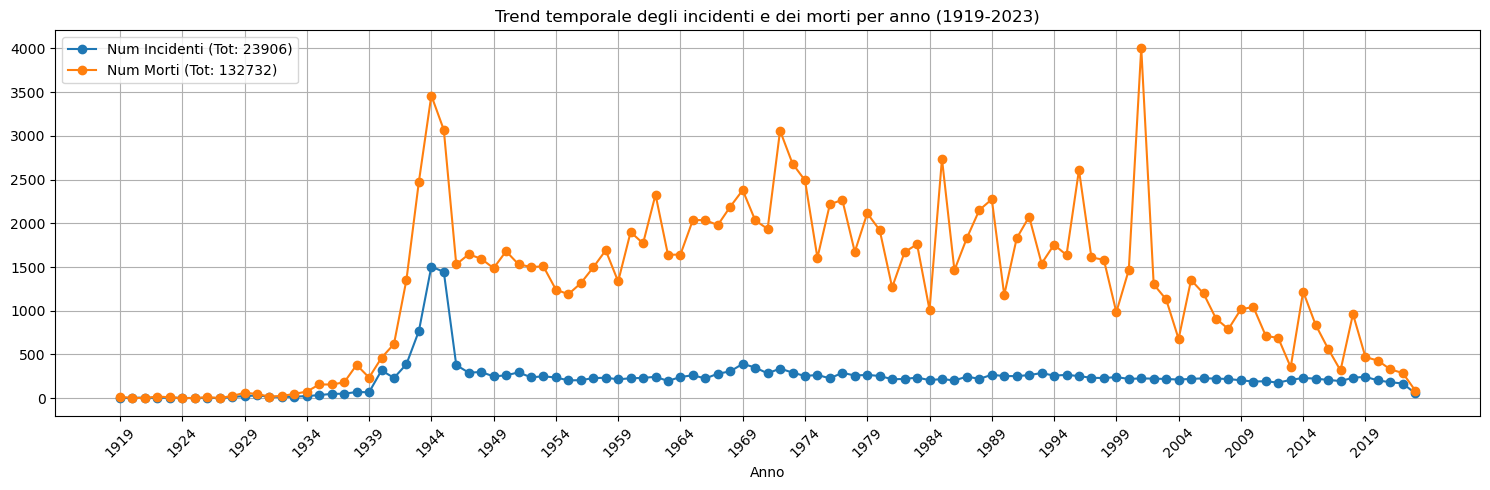

Si può notare dal grafico un picco significativo durante gli anni della Seconda Guerra Mondiale.
Per quanto riguarda i morti si ha un ulteriore picco nell'incidente dell'11 Settembre 2001.
Analizziamo ora il trend suddiviso nelle principali epoche di questo secolo


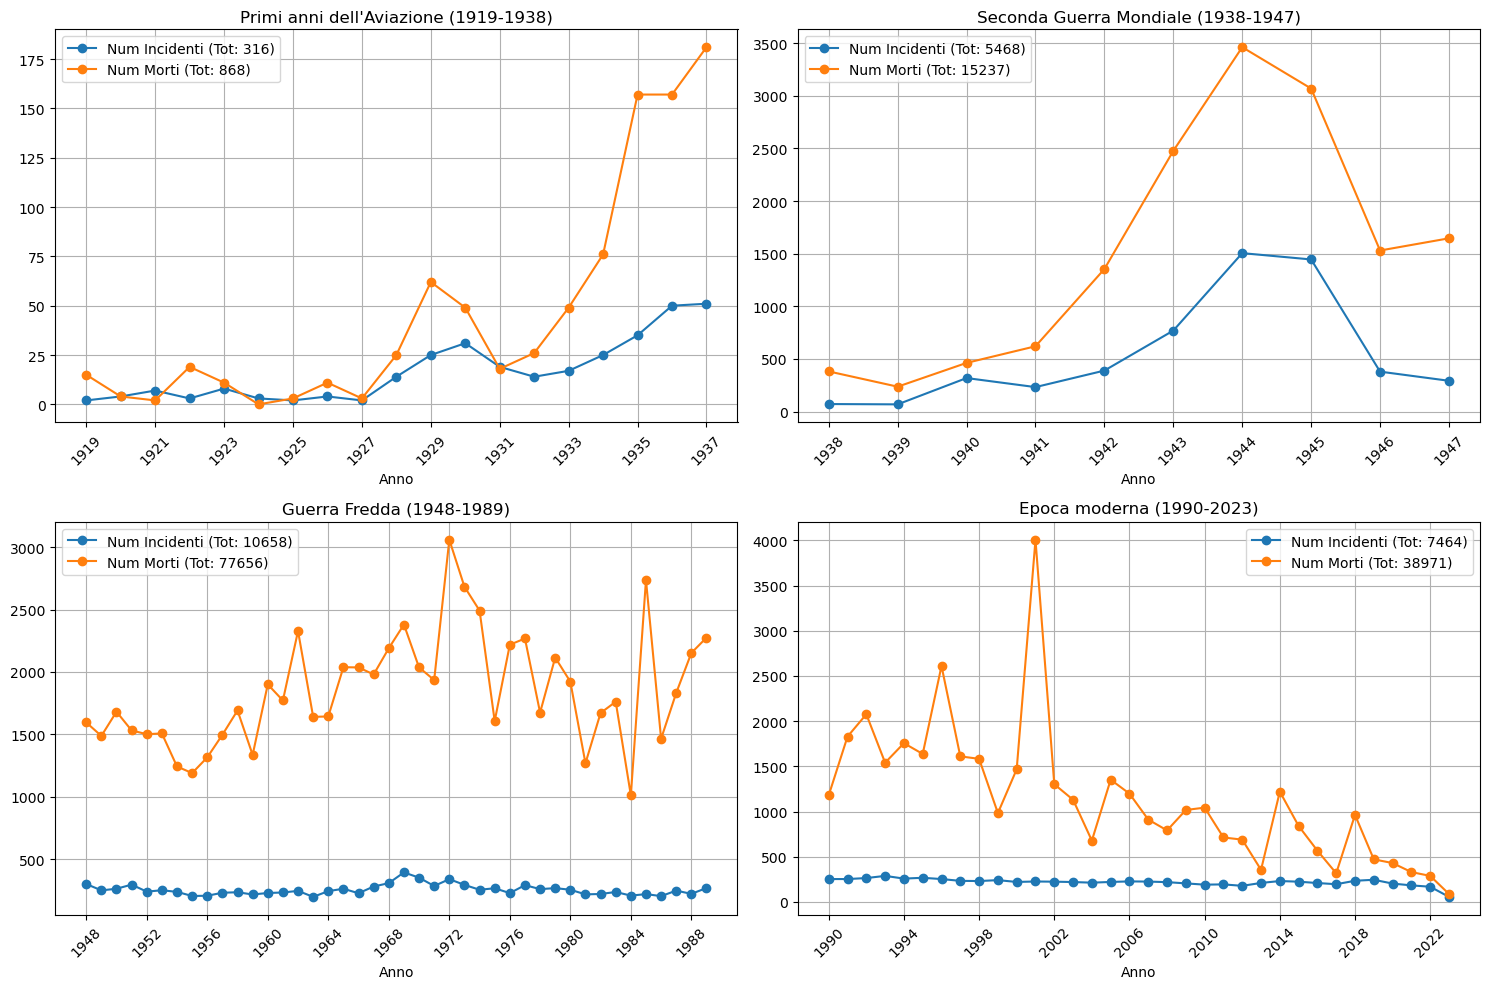

Come ci si aspettava nel primo periodo il numero di incidenti aerei è basso per via del limitato traffico aereo presente.
L'impennata di incidenti si ha nel periodo della Seconda Guerra Mondiale.
Nell'epoca della Guerra Fredda il numero di incidenti per anno rimane stabile, anche se il numero dei morti rimane
significativo per via dell'aumento del traffico aereo e delle continue guerre sparse per il globo.
Nell'epoca moderna si può notare come, grazie all'innovazione tecnoglica e un aumento dei controlli di sicurezza, il numero
di incidenti sia stabile, anche se il numero dei morti rimane elevato, per via dell'aumento dei passeggeri nei voli.
Si può notare un trend di diminuizione dei morti dopo l'11 Settembre.


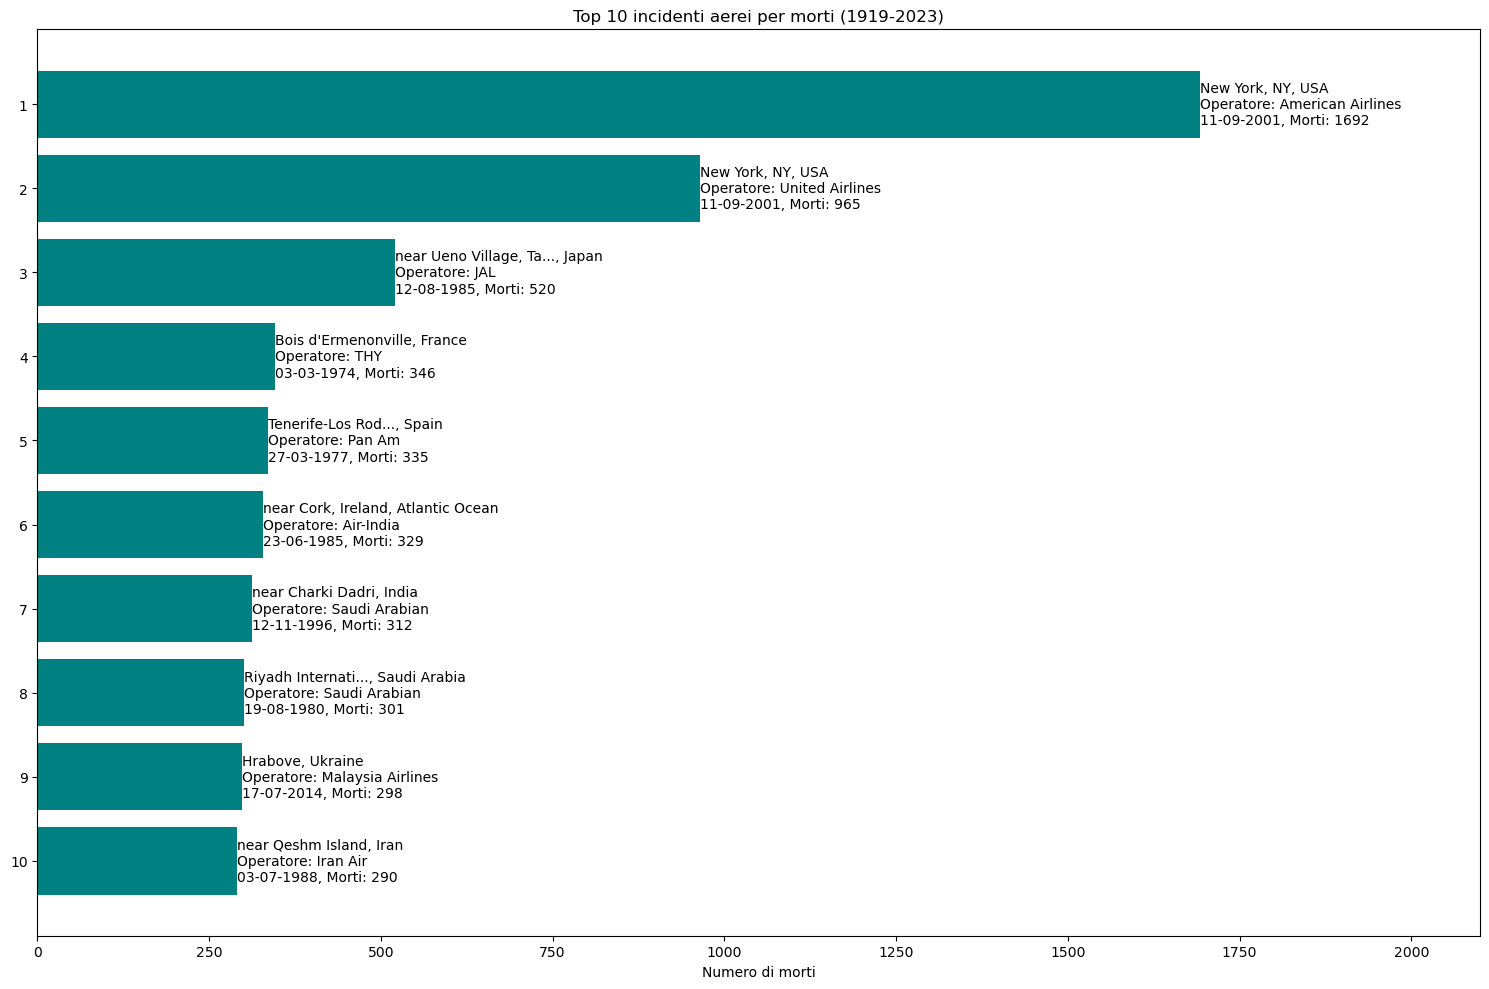

Da questo punto si prendono in considerazione gli incidenti avvenuti dopo il 1947, in modo da poter fare un'analisi
più accurata, riuscendo a separare meglio gli incidenti militari e quelli civili; in quanto ci si aspetta che durante
gli anni della Seconda Guerra Mondiale anche gli aree civili venivano utilizzati a scopo militare


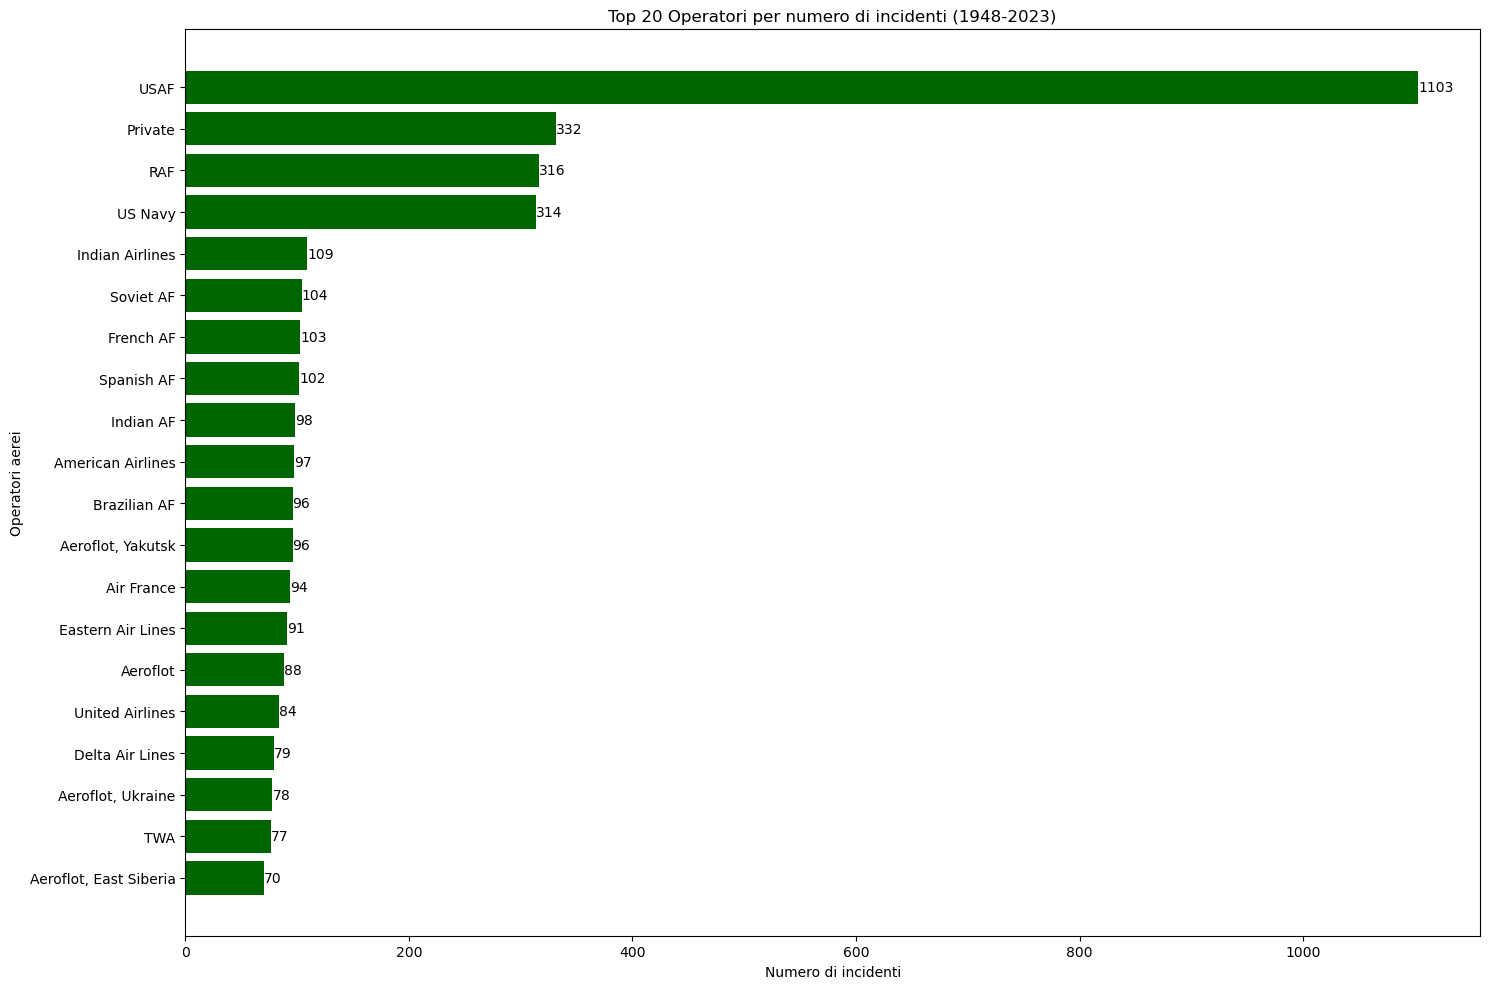

Dal grafico si nota come la maggior parte degli operatori più coinvolti negli incidenti siano di origine militare,
in quanto nella TOP20 sono presenti diverse Air Force delle rispettive nazioni.
Quindi si suddivide il dataset in operatori militari e civili per proseguire le analisi


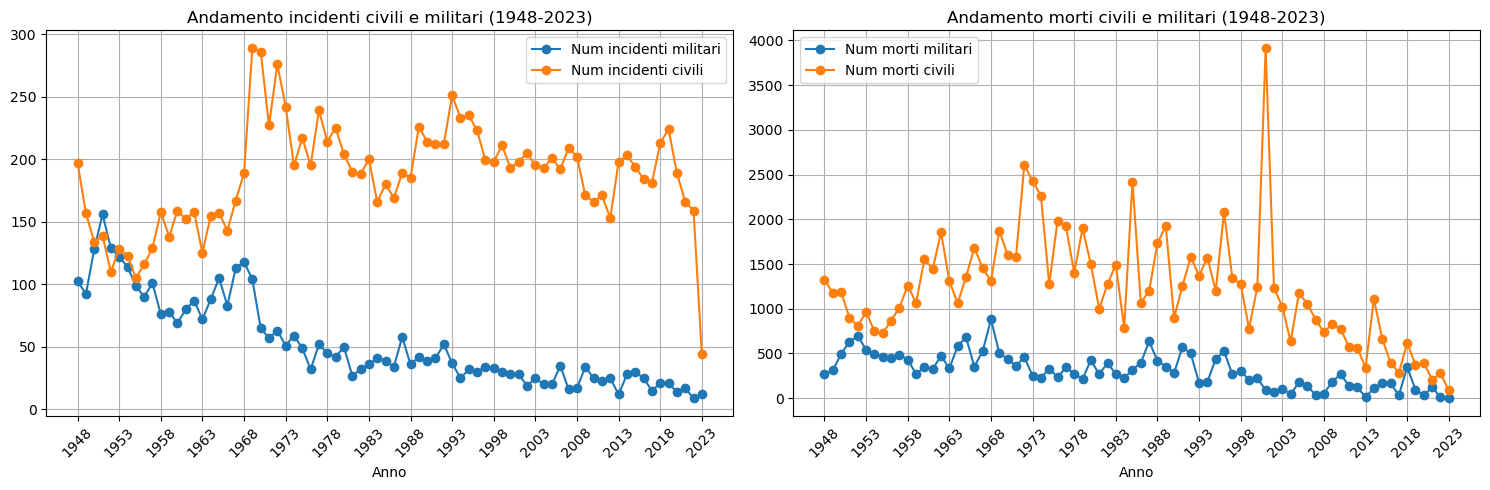

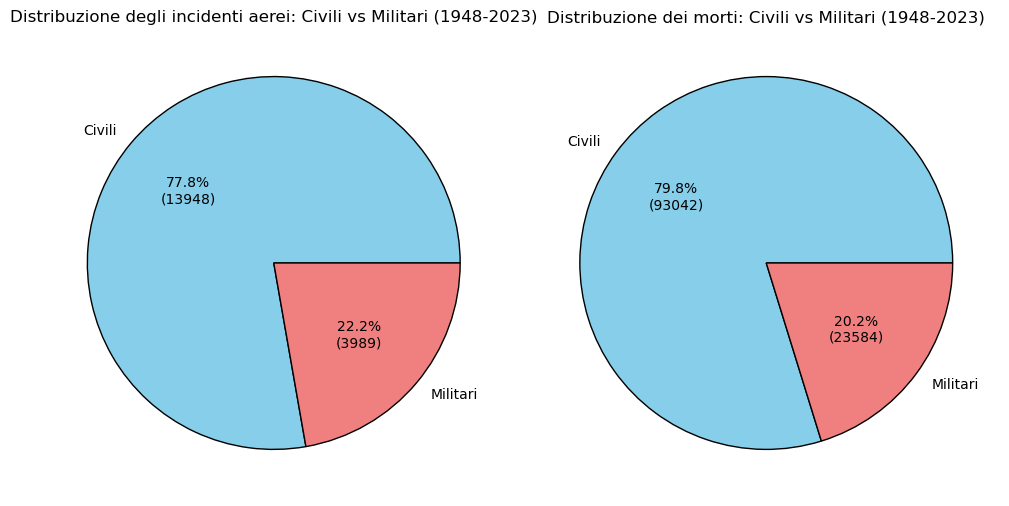

Dai grafici prevale il fatto che nonostante gli operatori militari siano più coinvolti in incidenti aerei, nel complesso,
sia per numero di incidenti che per numero di morti, gli operatori civili superano di gran lunga quelli militari.
Questo perchè non ci sono state grandi guerre dopo il 1950, il traffico aereo civile è aumentato, trasportando
sempre più passeggeri, mentre in un incidente di natura militare sono coinvolti solamente i piloti.

Considerando solo gli incidenti di operatori civili si vuole capire se un alto numero di incidenti corrisponde anche ad un alto numero di morti.
(Si escludono dal conteggio gli incidenti dell'11 Settembre con  2657  morti e gli operatori Privati che hanno un alto numero di incidenti ( 332 ) e un basso numero di morti ( 305 )


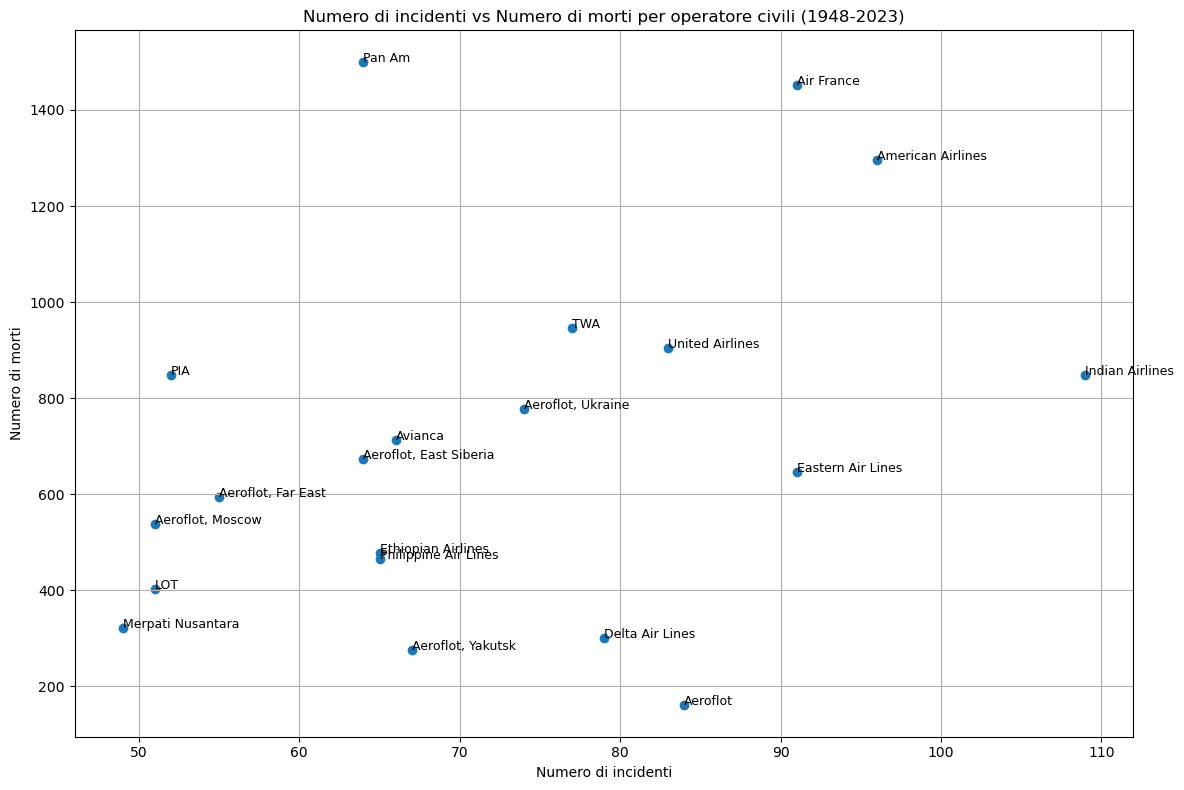


Considerando solo gli incidenti di operatori civili, illustriamo la distribuzione nei mesi e nei giorni della settimana,
per capire quanto la distribuzione sia uniforme


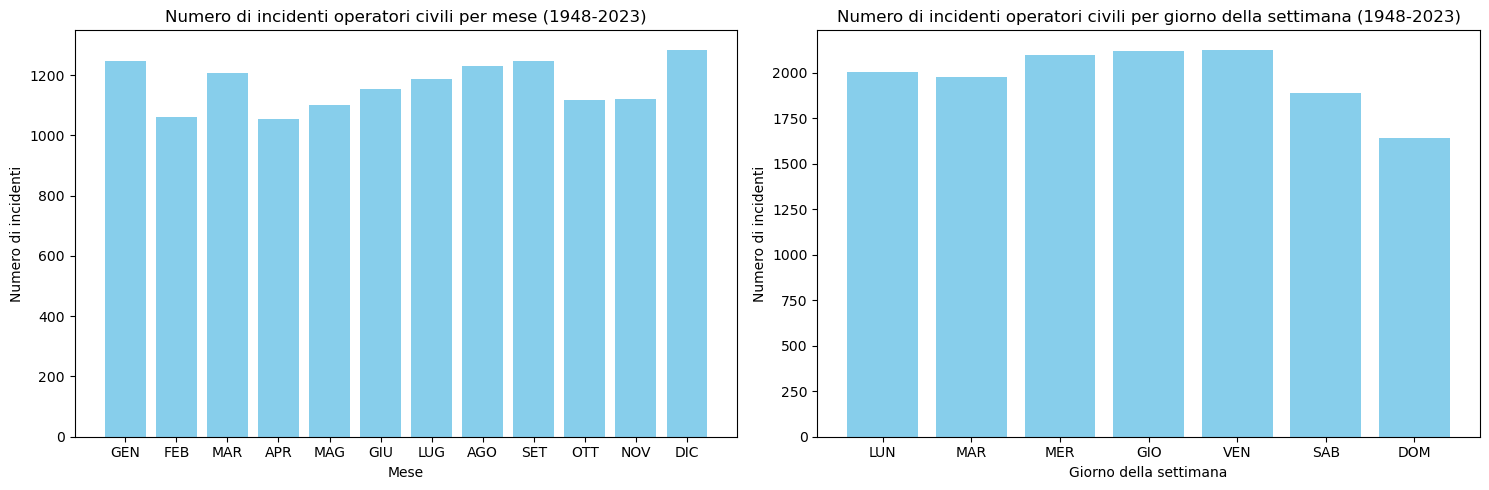

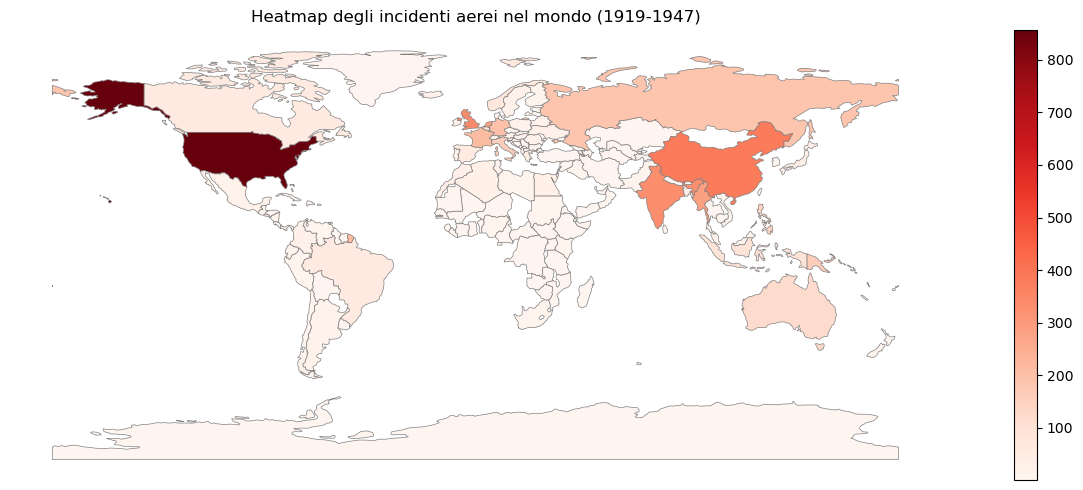

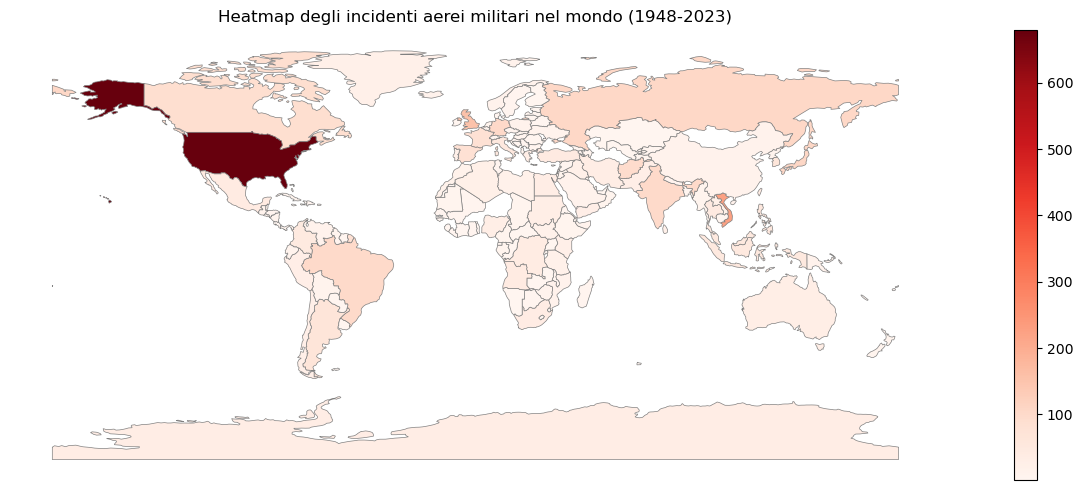

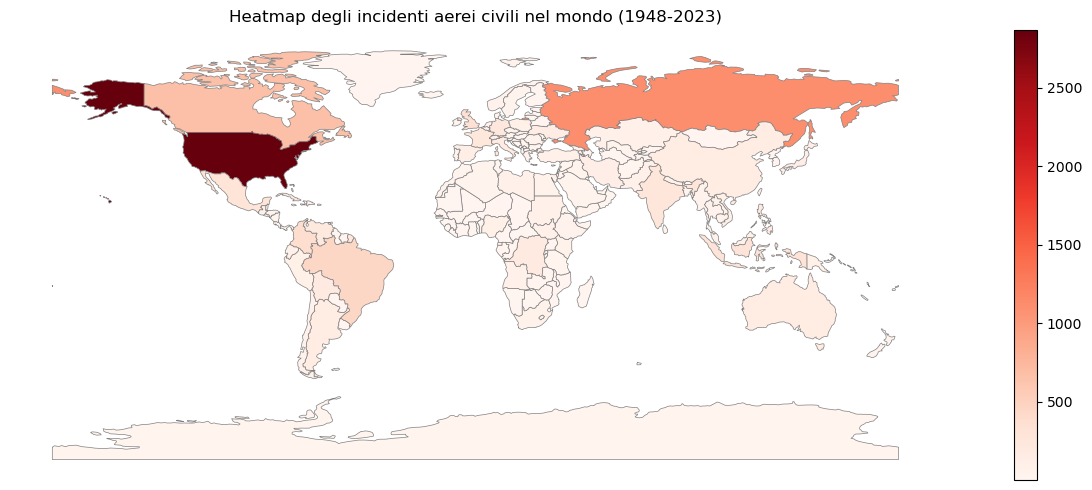

In [1]:
#--- LIBRERIE ---#

import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from datetime import datetime

#--- FUNZIONI ---#

def extract_year(date_str):
    if pd.isnull(date_str):
        return None
    try:
        parts = date_str.split('-')
        if '????' in parts[2]:
            return None
        return int(parts[2])
    except (IndexError, AttributeError):
        return None

def extract_month(date_str):
    if pd.isnull(date_str):
        return None
    try:
        parts = date_str.split('-')
        if '???' in parts[1]:
            return None
        return parts[1]
    except (IndexError, AttributeError):
        return None

def replace_unknowns(value):
    if pd.isnull(value) or 'unknown' in value.lower() or '?' in value:
        return None
    if value == 'private':
        return 'Private'
    return value

def clean_fatalities(value):
    if pd.isnull(value):
        return None
    try:
        value = value.replace(" ", "")
        if '+' in value:
            parts = value.split('+')
            return sum(int(part) for part in parts if part.isdigit())
        elif value.isdigit():
            return int(value)
        else:
            return None
    except ValueError:
        return None
    
def format_func(pct, values):
    absolute = int(pct/100.*sum(values))
    return "{:.1f}%\n({:d})".format(pct, absolute)
    
#--- MAIN ---#
    
# Creazione dataframe da file csv
df = pd.read_csv("aviation-accidents.csv")
#print("Info dataframe iniziale\n")
#print(df.info())

## PULIZIA DATASET ##
#colonna 'date'
df['date'] = df['date'].replace('date unk.',None)

#creazione colonna 'year'
df['year'] = df['date'].apply(extract_year)
df['year'] = df['year'].astype('Int64')

#creazione colonnea 'month'
df['month'] = df['date'].apply(extract_month)
mapping = {'JAN':'GEN','FEB':'FEB','MAR':'MAR','APR':'APR',
           'MAY':'MAG','JUN':'GIU','JUL':'LUG','AUG':'AGO',
           'SEP':'SET','OCT':'OTT','NOV':'NOV','DEC':'DIC'}
df['month'] = df['month'].map(mapping)

#da str a datetime
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%Y', errors='coerce')

#creazione colonna 'week_day'
df['week_day'] = df['date'].dt.day_name()
mapping = {'Monday':'LUN', 'Tuesday':'MAR', 'Wednesday':'MER', 'Thursday':'GIO',
           'Friday':'VEN', 'Saturday':'SAB', 'Sunday':'DOM'}
df['week_day'] = df['week_day'].map(mapping)

#pulizia colonne con stringhe
clean_columns = ['type','operator','location','country','cat']

for i in clean_columns:
    df[i] = df[i].apply(replace_unknowns)

#pulizia colonna 'fatalities'
df['fatalities'] = df['fatalities'].apply(clean_fatalities)
df['fatalities'] = df['fatalities'].astype('Int64')

#print("\nInfo dataframe dopo la pulizia\n")
#print(df.info())

## VISUALIZZAZIONE INSIGHT ##

print("Analizziamo il trend temporale degli incidenti e dei morti nell'arco che va dal 1919 al 2023")

# Subset Dataframe
incidents_year = df.groupby('year').size()
fatalities_year = df.groupby('year')['fatalities'].sum()
df_subset = pd.DataFrame({ 'year': incidents_year.index,
                           'incidents': incidents_year.values,
                           'fatalities': fatalities_year.values })

# Andamento temporale 1919-2023 #
plt.figure(figsize=(15, 5))
plt.plot(df_subset['year'], df_subset['incidents'], marker='o', label='Num Incidenti (Tot: '+str(df_subset['incidents'].sum())+')')
plt.plot(df_subset['year'], df_subset['fatalities'], marker='o', label='Num Morti (Tot: '+str(df_subset['fatalities'].sum())+')')
plt.title('Trend temporale degli incidenti e dei morti per anno (1919-2023)')
plt.xlabel('Anno')
plt.xticks(range(df_subset['year'].min(), df_subset['year'].max(), 5), rotation=45)
plt.legend(loc="upper left")
plt.grid()

plt.tight_layout()
plt.show()

print("Si può notare dal grafico un picco significativo durante gli anni della Seconda Guerra Mondiale."+
      "\nPer quanto riguarda i morti si ha un ulteriore picco nell'incidente dell'11 Settembre 2001."+
      "\nAnalizziamo ora il trend suddiviso nelle principali epoche di questo secolo")

# Divisione in epoche 
first_aviation = df_subset[df_subset['year'] < 1938]
world_war_2 =  df_subset[(df_subset['year'] >= 1938) & (df_subset['year'] < 1948)]
cold_war = df_subset[(df_subset['year'] >= 1948) & (df_subset['year'] < 1990)]
modern_era = df_subset[df_subset['year'] >= 1990]

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# First Aviation (1919-1938)
ax[0, 0].plot(first_aviation['year'], first_aviation['incidents'], marker='o', label='Num Incidenti (Tot: '+str(first_aviation['incidents'].sum())+')')
ax[0, 0].plot(first_aviation['year'], first_aviation['fatalities'], marker='o', label='Num Morti (Tot: '+str(first_aviation['fatalities'].sum())+')')
ax[0, 0].set_title("Primi anni dell'Aviazione (1919-1938)")
ax[0, 0].set_xlabel('Anno')
ax[0, 0].legend(loc="upper left")
ax[0, 0].grid()
ax[0, 0].set_xticks(range(first_aviation['year'].min(), first_aviation['year'].max()+1, 2))
ax[0, 0].tick_params(axis='x', rotation=45)

# World War 2 (1939-1947)
ax[0, 1].plot(world_war_2['year'], world_war_2['incidents'], marker='o', label='Num Incidenti (Tot: '+str(world_war_2['incidents'].sum())+')')
ax[0, 1].plot(world_war_2['year'], world_war_2['fatalities'], marker='o', label='Num Morti (Tot: '+str(world_war_2['fatalities'].sum())+')')
ax[0, 1].set_title('Seconda Guerra Mondiale (1938-1947)')
ax[0, 1].set_xlabel('Anno')
ax[0, 1].legend(loc="upper left")
ax[0, 1].grid()
ax[0, 1].set_xticks(range(world_war_2['year'].min(), world_war_2['year'].max()+1, 1))
ax[0, 1].tick_params(axis='x', rotation=45)

# Cold War (1948-1989)
ax[1, 0].plot(cold_war['year'], cold_war['incidents'], marker='o', label='Num Incidenti (Tot: '+str(cold_war['incidents'].sum())+')')
ax[1, 0].plot(cold_war['year'], cold_war['fatalities'], marker='o', label='Num Morti (Tot: '+str(cold_war['fatalities'].sum())+')')
ax[1, 0].set_title('Guerra Fredda (1948-1989)')
ax[1, 0].set_xlabel('Anno')
ax[1, 0].legend(loc="upper left")
ax[1, 0].grid()
ax[1, 0].set_xticks(range(cold_war['year'].min(), cold_war['year'].max()+1, 4))
ax[1, 0].tick_params(axis='x', rotation=45)

# Modern Era (1990-2023)
ax[1, 1].plot(modern_era['year'], modern_era['incidents'], marker='o', label='Num Incidenti (Tot: '+str(modern_era['incidents'].sum())+')')
ax[1, 1].plot(modern_era['year'], modern_era['fatalities'], marker='o', label='Num Morti (Tot: '+str(modern_era['fatalities'].sum())+')')
ax[1, 1].set_title('Epoca moderna (1990-2023)')
ax[1, 1].set_xlabel('Anno')
ax[1, 1].legend(loc="upper right")
ax[1, 1].grid()
ax[1, 1].set_xticks(range(modern_era['year'].min(), modern_era['year'].max()+1, 4))
ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Come ci si aspettava nel primo periodo il numero di incidenti aerei è basso per via del limitato traffico aereo presente."+
      "\nL'impennata di incidenti si ha nel periodo della Seconda Guerra Mondiale."+
      "\nNell'epoca della Guerra Fredda il numero di incidenti per anno rimane stabile, anche se il numero dei morti rimane"+
      "\nsignificativo per via dell'aumento del traffico aereo e delle continue guerre sparse per il globo."
      "\nNell'epoca moderna si può notare come, grazie all'innovazione tecnoglica e un aumento dei controlli di sicurezza, il numero"+
      "\ndi incidenti sia stabile, anche se il numero dei morti rimane elevato, per via dell'aumento dei passeggeri nei voli."+
      "\nSi può notare un trend di diminuizione dei morti dopo l'11 Settembre.")

# Top 10 incidenti aerei per morti (1919-2023) #
top_10_incidents = df.nlargest(10, 'fatalities')

plt.figure(figsize=(15, 10))
bars = plt.barh(range(1,11,1), top_10_incidents['fatalities'], color='teal')
plt.xlabel('Numero di morti')
plt.title('Top 10 incidenti aerei per morti (1919-2023)')
plt.yticks(range(1,11,1))
plt.xlim(0,2100)
plt.gca().invert_yaxis()

for bar, date, location, country, operator in zip(bars, top_10_incidents['date'],top_10_incidents['location'],top_10_incidents['country'],top_10_incidents['operator']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
        f'{location}, {country}\nOperatore: {operator}\n{date.strftime("%d-%m-%Y")}, Morti: {int(bar.get_width())}', 
        va='center', ha='left')
    
plt.tight_layout()
plt.show()

print("Da questo punto si prendono in considerazione gli incidenti avvenuti dopo il 1947, in modo da poter fare un'analisi"+
      "\npiù accurata, riuscendo a separare meglio gli incidenti militari e quelli civili; in quanto ci si aspetta che durante"+
      "\ngli anni della Seconda Guerra Mondiale anche gli aree civili venivano utilizzati a scopo militare")

#Filtro dataset dal 1947
df_filtered = df[df['year']>1947]

# Top 20 Operatori aerei (1948-2023) #
operator_counts = df_filtered['operator'].value_counts().reset_index()
operator_counts.columns = ['operator','incidents']

plt.figure(figsize=(15, 10))
bars = plt.barh(operator_counts.head(20)['operator'], operator_counts.head(20)['incidents'], color='darkgreen')
plt.xlabel('Numero di incidenti')
plt.ylabel('Operatori aerei')
plt.title('Top 20 Operatori per numero di incidenti (1948-2023)')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width())}', 
             va='center', ha='left')
    
plt.tight_layout()
plt.show()

print("Dal grafico si nota come la maggior parte degli operatori più coinvolti negli incidenti siano di origine militare,"+
      "\nin quanto nella TOP20 sono presenti diverse Air Force delle rispettive nazioni."+
      "\nQuindi si suddivide il dataset in operatori militari e civili per proseguire le analisi")

#Filtro dataframe solo e senza operatori AF
pattern = 'AF|army|navy'
df_only_af = df_filtered[df_filtered['operator'].str.contains(pattern, case=False, na=False)]
df_without_af = df_filtered[~df_filtered['operator'].str.contains(pattern, case=False, na=False)]

# Incidenti e morti operatori civili e militari (1948-2023) #
incidents_only_af_year = df_only_af.groupby('year').size()
fatalities_only_af_year = df_only_af.groupby('year')['fatalities'].sum()
incidents_without_af_year = df_without_af.groupby('year').size()
fatalities_without_af_year = df_without_af.groupby('year')['fatalities'].sum()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Incidenti
ax[0].plot(incidents_only_af_year.index, incidents_only_af_year.values, marker='o', label='Num incidenti militari')
ax[0].plot(incidents_without_af_year.index, incidents_without_af_year.values, marker='o', label='Num incidenti civili')
ax[0].set_title("Andamento incidenti civili e militari (1948-2023)")
ax[0].set_xlabel('Anno')
ax[0].legend(loc="upper right")
ax[0].grid()
ax[0].set_xticks(range(incidents_only_af_year.index.min(), incidents_only_af_year.index.max()+1, 5))
ax[0].tick_params(axis='x', rotation=45)

# Morti
ax[1].plot(fatalities_only_af_year.index, fatalities_only_af_year.values, marker='o', label='Num morti militari')
ax[1].plot(fatalities_without_af_year.index, fatalities_without_af_year.values, marker='o', label='Num morti civili')
ax[1].set_title("Andamento morti civili e militari (1948-2023)")
ax[1].set_xlabel('Anno')
ax[1].legend(loc="upper left")
ax[1].grid()
ax[1].set_xticks(range(fatalities_only_af_year.index.min(), fatalities_only_af_year.index.max()+1, 5))
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Distribuzione degli incidenti civili vs militari (1948-2023) #
operator_counts = df_without_af['operator'].value_counts().reset_index()
operator_counts.columns = ['operator','incidents']
operator_af_counts = df_only_af['operator'].value_counts().reset_index()
operator_af_counts.columns = ['operator','incidents']

fig, ax = plt.subplots(1, 2, figsize=(10,5))
    
incidents = [operator_counts['incidents'].sum(),operator_af_counts['incidents'].sum()]

ax[0].pie(incidents, labels=["Civili", "Militari"], 
        autopct=lambda pct: format_func(pct, incidents), 
        colors=['skyblue', 'lightcoral'], wedgeprops={'edgecolor': 'black'})
ax[0].set_title('Distribuzione degli incidenti aerei: Civili vs Militari (1948-2023)')

# Distribuzione dei morti civili vs militari (1948-2023) #
fatalities = [df_without_af['fatalities'].sum(),df_only_af['fatalities'].sum()]

ax[1].pie(fatalities, labels=["Civili", "Militari"], 
        autopct=lambda pct: format_func(pct, fatalities), 
        colors=['skyblue', 'lightcoral'], wedgeprops={'edgecolor': 'black'})
ax[1].set_title('Distribuzione dei morti: Civili vs Militari (1948-2023)')

plt.tight_layout()
plt.show()

print("Dai grafici prevale il fatto che nonostante gli operatori militari siano più coinvolti in incidenti aerei, nel complesso,"+
      "\nsia per numero di incidenti che per numero di morti, gli operatori civili superano di gran lunga quelli militari."+
      "\nQuesto perchè non ci sono state grandi guerre dopo il 1950, il traffico aereo civile è aumentato, trasportando"+
      "\nsempre più passeggeri, mentre in un incidente di natura militare sono coinvolti solamente i piloti.")

print("\nConsiderando solo gli incidenti di operatori civili si vuole capire se un alto numero di incidenti corrisponde anche ad un alto numero di morti."+
      "\n(Si escludono dal conteggio gli incidenti dell'11 Settembre con ",df[df['fatalities']>900]['fatalities'].sum()," morti "+
      "e gli operatori Privati che hanno un alto numero di incidenti (",len(df_without_af[df_without_af["operator"]=='Private']),
      ") e un basso numero di morti (",df_without_af[df_without_af["operator"]=='Private']['fatalities'].sum(),")")

# Incidenti vs Morti per i TOP20 operatori #
df_scatter = df_without_af[~((df_without_af['fatalities'] > 900) | (df_without_af['operator']=='Private'))]
incidents_operator = df_scatter.groupby('operator').size()
fatalities_operator = df_scatter.groupby('operator')['fatalities'].sum()

data = pd.DataFrame({'incidents': incidents_operator, 'fatalities': fatalities_operator})

top_operators = data.sort_values(by='incidents', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.scatter(top_operators['incidents'], top_operators['fatalities'])
plt.xlabel('Numero di incidenti')
plt.ylabel('Numero di morti')
plt.title('Numero di incidenti vs Numero di morti per operatore civili (1948-2023)')
for i in range(top_operators.shape[0]):
    plt.text(top_operators['incidents'].iloc[i], top_operators['fatalities'].iloc[i], 
             top_operators.index[i], fontsize=9)
plt.grid()

plt.tight_layout()
plt.show()

print("\nConsiderando solo gli incidenti di operatori civili, illustriamo la distribuzione nei mesi e nei giorni della settimana,"+
      "\nper capire quanto la distribuzione sia uniforme")

# Incidenti per mese (1949-2023) senza operatori AF #
month_counts = df_without_af['month'].value_counts()
ord_mesi = ['GEN', 'FEB', 'MAR', 'APR', 'MAG', 'GIU', 'LUG', 'AGO', 'SET', 'OTT', 'NOV', 'DIC']
month_counts = month_counts.reindex(ord_mesi)

# Incidenti per giorno della settimana (1949-2023) senza operatori AF #
day_counts = df_without_af['week_day'].value_counts()
ord_day = ['LUN','MAR','MER','GIO','VEN','SAB','DOM']
day_counts = day_counts.reindex(ord_day)

fig, ax = plt.subplots(1, 2, figsize=(15,5))
#mese
ax[0].bar(month_counts.index, month_counts.values, color='skyblue')
ax[0].set_xlabel('Mese')
ax[0].set_ylabel('Numero di incidenti')
ax[0].set_title('Numero di incidenti operatori civili per mese (1948-2023)')
#giorni
ax[1].bar(day_counts.index, day_counts.values, color='skyblue')
ax[1].set_xlabel('Giorno della settimana')
ax[1].set_ylabel('Numero di incidenti')
ax[1].set_title('Numero di incidenti operatori civili per giorno della settimana (1948-2023)')

plt.tight_layout()
plt.show()

# Heatmap incidenti aerei (1919-1947) #
df_cartogram = df[df['year']<1948].copy()
name_cart = pd.read_csv("name_cart.csv") #nomi Paesi cartogramma
countries = pd.read_csv("countries.csv") #nomi Paesi dataset
mapping = dict(zip(countries['country'], name_cart['name']))
df_cartogram["country"] = df_cartogram["country"].map(mapping)

country_counts = df_cartogram['country'].value_counts().reset_index()
country_counts.columns = ['country', 'incidents']

world = gpd.read_file("cartogramma/ne_110m_admin_0_countries.shp")

world = world.merge(country_counts, how='left', left_on='NAME_EN', right_on='country')

fig, ax = plt.subplots(figsize=(15, 5))
world.plot(column='incidents', cmap='Reds', linewidth=0.5, ax=ax, edgecolor='0.5', legend=True)
ax.set_title('Heatmap degli incidenti aerei nel mondo (1919-1947)')
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Heatmap incidenti aerei militari (1948-2023) #
df_cartogram = df_only_af.copy()
df_cartogram["country"] = df_cartogram["country"].map(mapping) 

country_counts = df_cartogram['country'].value_counts().reset_index()
country_counts.columns = ['country', 'incidents']

world = gpd.read_file("cartogramma/ne_110m_admin_0_countries.shp")

world = world.merge(country_counts, how='left', left_on='NAME_EN', right_on='country')

fig, ax = plt.subplots(figsize=(15, 5))
world.plot(column='incidents', cmap='Reds', linewidth=0.5, ax=ax, edgecolor='0.5', legend=True)
ax.set_title('Heatmap degli incidenti aerei militari nel mondo (1948-2023)')
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Heatmap incidenti aerei civili (1948-2023) #
df_cartogram = df_without_af.copy()
df_cartogram["country"] = df_cartogram["country"].map(mapping)

country_counts = df_cartogram['country'].value_counts().reset_index()
country_counts.columns = ['country', 'incidents']

world = gpd.read_file("cartogramma/ne_110m_admin_0_countries.shp")

world = world.merge(country_counts, how='left', left_on='NAME_EN', right_on='country')

fig, ax = plt.subplots(figsize=(15, 5))
world.plot(column='incidents', cmap='Reds', linewidth=0.5, ax=ax, edgecolor='0.5', legend=True)
ax.set_title('Heatmap degli incidenti aerei civili nel mondo (1948-2023)')
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.set_axis_off()

plt.tight_layout()
plt.show()

